# Amazon Reviews 2023 — 샘플 데이터 탐색

**데이터셋**: [McAuley-Lab/Amazon-Reviews-2023](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023)  
**참고**: https://amazon-reviews-2023.github.io/

## 구조
| 종류 | HuggingFace config 형식 | 내용 |
|------|------------------------|------|
| 리뷰 | `raw_review_{카테고리}` | rating, text, user_id, asin, timestamp 등 |
| 메타 | `raw_meta_{카테고리}` | 상품명, 가격, 설명, 카테고리 등 |

이 노트북에서는 **All_Beauty** 카테고리로 먼저 탐색합니다 (가장 작은 카테고리 중 하나).

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

CATEGORY = "All_Beauty"

## 1. 리뷰 데이터 로드

In [2]:
review_ds = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    f"raw_review_{CATEGORY}",
)
print(review_ds)

Generating full split: 0 examples [00:00, ? examples/s]

DatasetDict({
    full: Dataset({
        features: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'],
        num_rows: 701528
    })
})


In [3]:
# DataFrame 변환 (전체)
review_df = review_ds["full"].to_pandas()
print(f"리뷰 수: {len(review_df):,}")
review_df.head(3)

리뷰 수: 701,528


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True


In [4]:
# 컬럼 & 타입 확인
review_df.dtypes

rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

## 2. 메타데이터 로드

In [5]:
meta_ds = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    f"raw_meta_{CATEGORY}",
    split="full",
)
meta_df = meta_ds.to_pandas()
print(f"상품 수: {len(meta_df):,}")
meta_df.head(3)

Generating full split:   0%|          | 0/112590 [00:00<?, ? examples/s]

상품 수: 112,590


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; ...",B01CUPMQZE,None,None,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Pro...",B076WQZGPM,None,None,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m....","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,None,None,None


In [6]:
meta_df.dtypes

main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price               object
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together     object
subtitle            object
author              object
dtype: object

## 3. 기본 통계 탐색

In [7]:
# 고유 사용자 / 상품 수
print(f"고유 사용자 수 : {review_df['user_id'].nunique():,}")
print(f"고유 상품 수   : {review_df['parent_asin'].nunique():,}")
print(f"평균 평점      : {review_df['rating'].mean():.2f}")
print(f"평점 분포:\n{review_df['rating'].value_counts().sort_index()}")

고유 사용자 수 : 631,986
고유 상품 수   : 112,565
평균 평점      : 3.96
평점 분포:
rating
1.0    102080
2.0     43034
3.0     56307
4.0     79381
5.0    420726
Name: count, dtype: int64


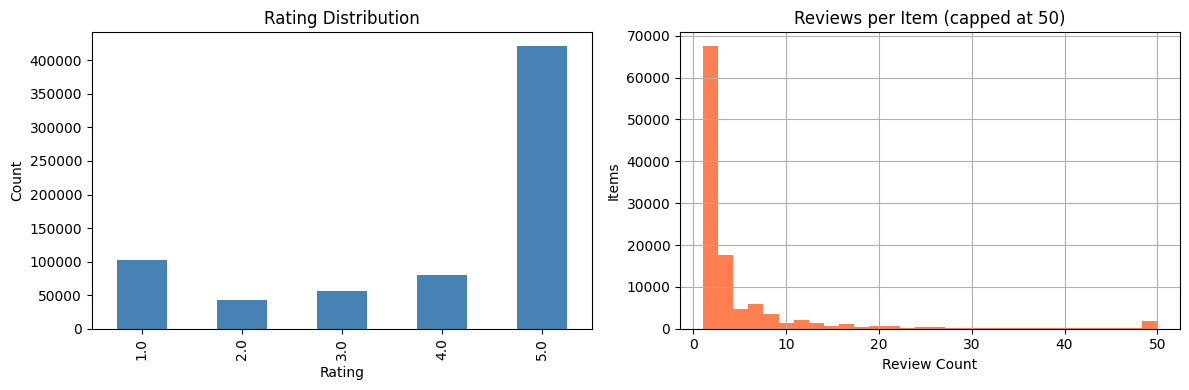

In [8]:
# 평점 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

review_df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# 상품별 리뷰 수 분포 (상위 50개)
reviews_per_item = review_df.groupby('parent_asin').size()
reviews_per_item.clip(upper=50).hist(bins=30, ax=axes[1], color='coral')
axes[1].set_title('Reviews per Item (capped at 50)')
axes[1].set_xlabel('Review Count')
axes[1].set_ylabel('Items')

plt.tight_layout()
plt.show()

## 4. 추천 시스템 관점 — 희소성 확인

실제 추천 모델에서 중요한 지표인 **interaction matrix sparsity** 를 확인합니다.

In [9]:
n_users = review_df['user_id'].nunique()
n_items = review_df['parent_asin'].nunique()
n_interactions = len(review_df)

sparsity = 1 - (n_interactions / (n_users * n_items))

print(f"Users        : {n_users:,}")
print(f"Items        : {n_items:,}")
print(f"Interactions : {n_interactions:,}")
print(f"Sparsity     : {sparsity:.4%}")

Users        : 631,986
Items        : 112,565
Interactions : 701,528
Sparsity     : 99.9990%


## 5. 리뷰 + 메타 조인 — 샘플 확인

In [12]:
meta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112590 entries, 0 to 112589
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   main_category    112590 non-null  object 
 1   title            112590 non-null  object 
 2   average_rating   112590 non-null  float64
 3   rating_number    112590 non-null  int64  
 4   features         112590 non-null  object 
 5   description      112590 non-null  object 
 6   price            112590 non-null  object 
 7   images           112590 non-null  object 
 8   videos           112590 non-null  object 
 9   store            101259 non-null  object 
 10  categories       112590 non-null  object 
 11  details          112590 non-null  object 
 12  parent_asin      112590 non-null  object 
 13  bought_together  0 non-null       object 
 14  subtitle         0 non-null       object 
 15  author           0 non-null       object 
dtypes: float64(1), int64(1), object(14)
me

In [14]:
# 메타에서 필요한 컬럼만 추출 후 조인
meta_slim = meta_df[['parent_asin', 'title', 'average_rating', 'price']].drop_duplicates('parent_asin')
del review_df['title']
joined = review_df.merge(meta_slim, on='parent_asin', how='left')
joined[['user_id', 'parent_asin', 'title', 'rating', 'text', 'price']].head(5)

,user_id,parent_asin,title,rating,text,price
0,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B00YQ6X8EO,Herbivore - Natural Sea Mist Texturizing Salt ...,5.0,This spray is really nice. It smells really go...,None
1,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B081TJ8YS3,All Natural Vegan Dry Shampoo Powder - Eco Fri...,4.0,"This product does what I need it to do, I just...",None
2,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,B097R46CSY,New Road Beauty - Creamsicle - Variety 3 Pack ...,5.0,"Smells good, feels great!",21.98
3,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B09JS339BZ,muaowig Ombre Body Wave Bundles 1B Grey Human ...,1.0,Felt synthetic,None
4,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B08BZ63GMJ,Yinhua Electric Nail Drill Kit Portable Profes...,5.0,Love it,None


## 6. 처리된 데이터 저장

다음 노트북(모델 학습)에서 바로 불러올 수 있도록 parquet으로 저장합니다.

In [15]:
import os

out_dir = f"../data/processed/{CATEGORY}"
os.makedirs(out_dir, exist_ok=True)

review_df.to_parquet(f"{out_dir}/reviews.parquet", index=False)
meta_df.to_parquet(f"{out_dir}/meta.parquet", index=False)

print(f"저장 완료 → {out_dir}/")

저장 완료 → ../data/processed/All_Beauty/
